Using device: cuda


<Figure size 1000x1000 with 0 Axes>

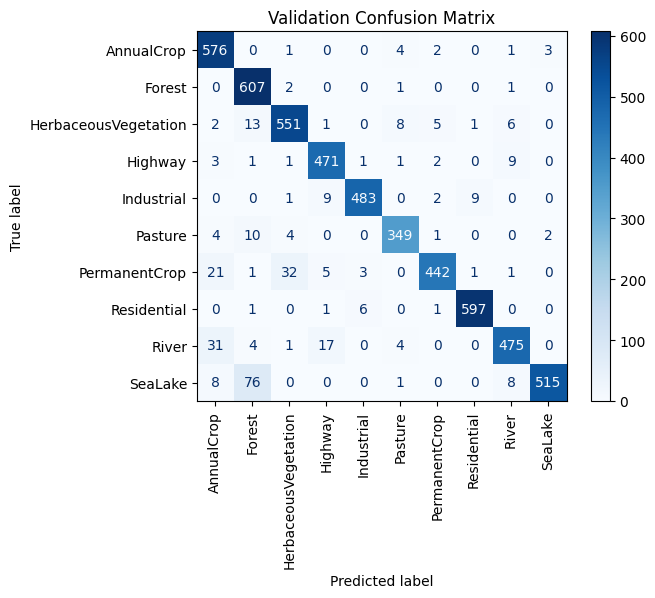

Showing 5 sample validation images with predictions:



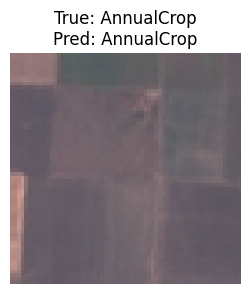

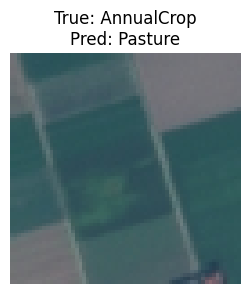

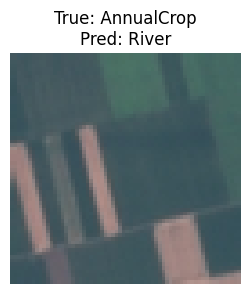

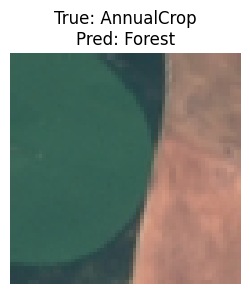

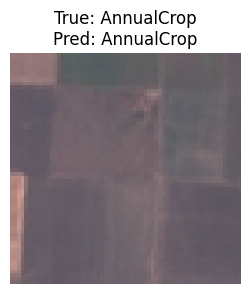

In [31]:
import os
import numpy as np
import torch
from torchvision import transforms, models, datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Adjust project root relative to the notebook location:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # notebooks/ -> project root

data_dir = os.path.join(project_root, "data")
output_dir = os.path.join(project_root, "outputs")

# Create outputs directory if it doesn't exist (optional)
os.makedirs(output_dir, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load saved predictions and labels
preds = np.load(os.path.join(output_dir, "preds.npy"))
labels = np.load(os.path.join(output_dir, "labels.npy"))

# Dataset normalization stats (EuroSAT RGB)
mean = [0.344, 0.380, 0.408]
std = [0.177, 0.150, 0.142]

# Dataset for class names and transforms (no download here)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

dataset = datasets.EuroSAT(root=data_dir, download=False, transform=transform)

# Class names
class_names = dataset.classes

# Load the model architecture and weights
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 10)
model.load_state_dict(torch.load(os.path.join(output_dir, "resnet18_eurosat.pth"), map_location=device))
model.to(device)
model.eval()

# Confusion matrix plot
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Validation Confusion Matrix")
plt.show()

# Function to show an image (unnormalizing for visualization)
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))  # CHW -> HWC
    img = img * np.array(std) + np.array(mean)  # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

print("Showing 5 sample validation images with predictions:\n")

for i in range(5):
    img, true_label = dataset[labels[i]]
    pred_label = preds[i]

    plt.figure(figsize=(3, 3))
    imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.show()


In [35]:
import os
import numpy as np
import pandas as pd
from torchvision.datasets import EuroSAT

# Set your paths
project_root = "/home/tony/Documents/eurosat_classification"
output_dir = os.path.join(project_root, "outputs")
data_dir = os.path.join(project_root, "data")

# Load predictions
labels = np.load(os.path.join(output_dir, "labels_epoch25.npy"))
preds = np.load(os.path.join(output_dir, "preds_epoch25.npy"))

labels = labels.flatten()
preds = preds.flatten()

# Get class names from dataset
class_names = EuroSAT(root=data_dir).classes
num_classes = len(class_names)

# Count correct predictions per class
class_correct = [0] * num_classes
class_total = [0] * num_classes

for true, pred in zip(labels, preds):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

# Build and print report
report = pd.DataFrame({
    "Class": class_names,
    "Correct": class_correct,
    "Total": class_total,
    "Accuracy (%)": [100 * c / t if t > 0 else 0 for c, t in zip(class_correct, class_total)]
}).sort_values("Accuracy (%)", ascending=True)

print(report.to_string(index=False))


               Class  Correct  Total  Accuracy (%)
          AnnualCrop      614    631     97.305864
       PermanentCrop      493    506     97.430830
HerbaceousVegetation      600    612     98.039216
               River      488    497     98.189135
             Pasture      391    396     98.737374
         Residential      600    606     99.009901
             Highway      521    525     99.238095
              Forest      578    582     99.312715
          Industrial      481    484     99.380165
             SeaLake      559    561     99.643494


🔍 Showing 5 misclassified images:



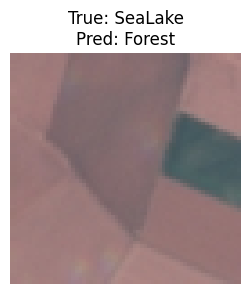

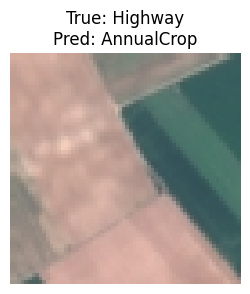

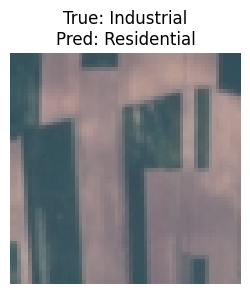

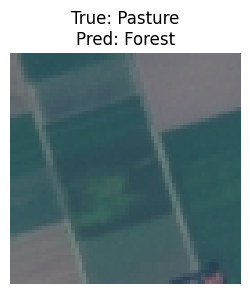

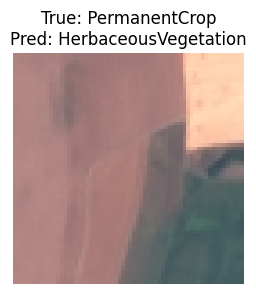

In [33]:
# Define inverse transform to undo normalization for display
inv_transform = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.], std=[1 / s for s in std]),
    transforms.Normalize(mean=[-m for m in mean], std=[1., 1., 1.]),
])

# Updated imshow function
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))  # Convert CHW to HWC
    img = np.clip(img, 0, 1)  # Clip values to [0, 1] for display
    plt.imshow(img)
    plt.axis('off')

print("🔍 Showing 5 misclassified images:\n")
shown = 0
i = 0
while shown < 5 and i < len(labels):
    if preds[i] != labels[i]:
        img, true_label = dataset[labels[i]]
        img_show = inv_transform(img)

        plt.figure(figsize=(3, 3))
        imshow(img_show)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.show()
        shown += 1
    i += 1


In [24]:
import torch
from sklearn.metrics import classification_report
import numpy as np

# Assuming you already have a validation dataloader
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Replace this with your actual class names
class_names = ['Forest', 'Urban', 'Water', 'Agriculture', 'Barren']

# Generate classification report
print(classification_report(y_true, y_pred, target_names=class_names))


NameError: name 'val_loader' is not defined